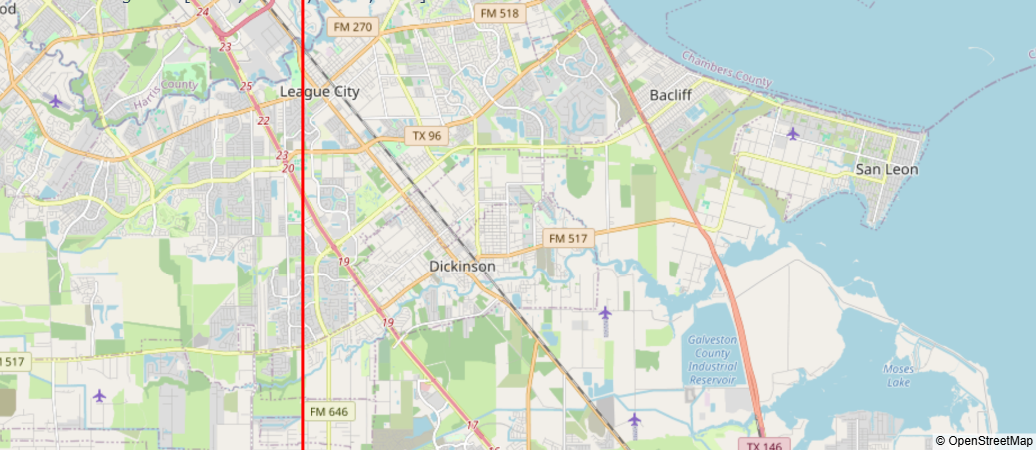

In [29]:
import plotly.graph_objects as go

extent = [-95.1, -94.45, 29.29, 29.8]

# Extract coordinates for the box
lons = [extent[0], extent[1], extent[1], extent[0], extent[0]]
lats = [extent[2], extent[2], extent[3], extent[3], extent[2]]

fig = go.Figure()

# Add bounding box
fig.add_trace(go.Scattermapbox(
    lon=lons,
    lat=lats,
    mode='lines',
    line=dict(width=3, color='red'),
    name='Bounding Box'
))

# Center map on the bounding box
center_lon = (extent[0] + extent[1]) / 2
center_lat = (extent[2] + extent[3]) / 2

fig.update_layout(
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=8
    ),
    margin={"r":0,"t":0,"l":0,"b":0},
    title="Bounding Box: [{}, {}, {}, {}]".format(*extent)
)

fig.show()


In [6]:
import numpy as np
import pandas as pd
import glob
import xarray as xr
import os
import matplotlib.pyplot as plt

#set current working directory
os.chdir('/home/jovyan')

#list files in shared folder
files = glob.glob("/shared_space/Galveston_Bay/*")
files


['/shared_space/Galveston_Bay/water_temp',
 '/shared_space/Galveston_Bay/MODIS_500',
 '/shared_space/Galveston_Bay/All_Observed_Data.csv',
 '/shared_space/Galveston_Bay/Observed_Raw',
 '/shared_space/Galveston_Bay/MODIS_test',
 '/shared_space/Galveston_Bay/MODIS_250',
 '/shared_space/Galveston_Bay/MODIS_files',
 '/shared_space/Galveston_Bay/ERA5']

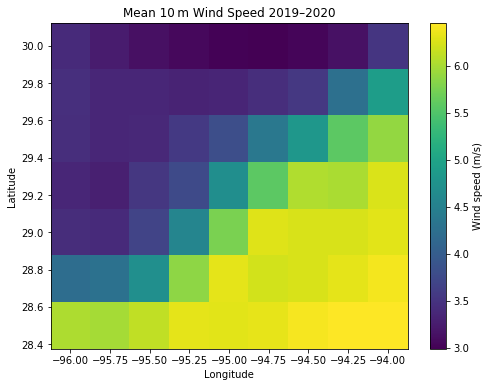

<xarray.Dataset>
Dimensions:     (latitude: 7, longitude: 9, valid_time: 17544)
Coordinates:
    number      int64 ...
  * latitude    (latitude) float64 30.0 29.75 29.5 29.25 29.0 28.75 28.5
  * longitude   (longitude) float64 -96.0 -95.75 -95.5 ... -94.5 -94.25 -94.0
  * valid_time  (valid_time) datetime64[ns] 2019-01-01 ... 2020-12-31T23:00:00
Data variables:
    u10         (valid_time, latitude, longitude) float32 ...
    v10         (valid_time, latitude, longitude) float32 ...
    wind_speed  (valid_time, latitude, longitude) float32 2.2622476 ... 10.449531
    ssr         (valid_time, latitude, longitude) float32 ...
    t2m         (valid_time, latitude, longitude) float32 ...

In [25]:
era5 = xr.open_dataset("/shared_space/Galveston_Bay/ERA5/ERA5-2019-2020_v3.nc")
era5

# Compute the mean wind speed over time
mean_wind_speed = era5['wind_speed'].mean(dim='valid_time')

# Plot the 2D spatial pattern
plt.figure(figsize=(8,6))
mean_wind_speed.plot(
    cmap='viridis',
    cbar_kwargs={'label': 'Wind speed (m/s)'}
)
plt.title("Mean 10 m Wind Speed 2019–2020")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
era5

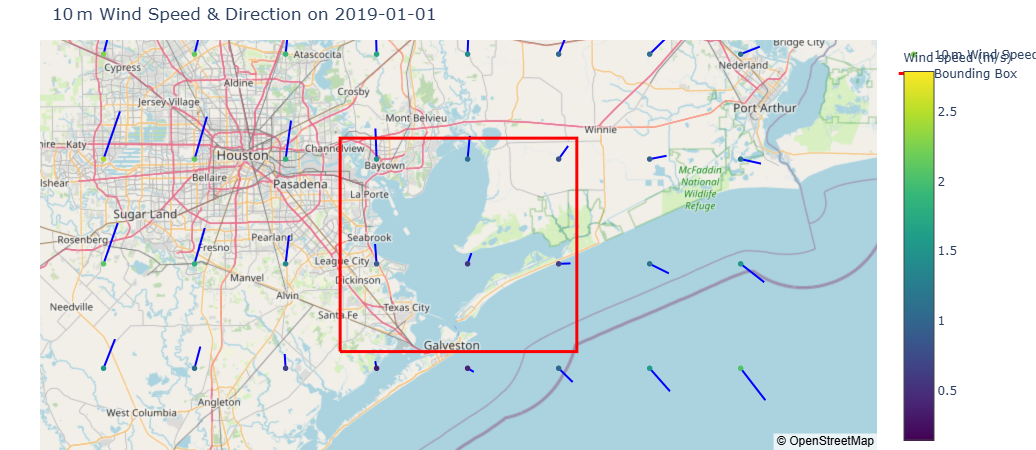

In [26]:
import xarray as xr
import numpy as np
import plotly.graph_objects as go

# --- Load dataset ---
ds = xr.open_dataset("/shared_space/Galveston_Bay/ERA5/ERA5-2019-2020_v3.nc")

# Pick a single time (replace with the desired date/time)
# Example: January 1, 2019, at 00:00
t_sel = np.datetime64("2019-01-01T00:00:00")

# Select the given time slice
u = ds["u10"].sel(valid_time=t_sel)
v = ds["v10"].sel(valid_time=t_sel)
speed = np.sqrt(u**2 + v**2)

# --- Coordinates and data ---
lons = u["longitude"].values
lats = u["latitude"].values
u_vals = u.values
v_vals = v.values
speed_vals = speed.values

# Subsample grid for clarity
sub = 1
lon2d, lat2d = np.meshgrid(lons, lats)
lon_s = lon2d[::sub, ::sub]
lat_s = lat2d[::sub, ::sub]
u_s = u_vals[::sub, ::sub]
v_s = v_vals[::sub, ::sub]
spd_s = speed_vals[::sub, ::sub]

# --- Compute arrow endpoints ---
arrow_scale = 0.05  # adjust arrow length
lon_end = lon_s + arrow_scale * u_s
lat_end = lat_s + arrow_scale * v_s

# Flatten arrays
lon_s, lat_s, lon_end, lat_end, spd_s = map(lambda x: x.flatten(),
                                            [lon_s, lat_s, lon_end, lat_end, spd_s])

# --- Bounding box ---
extent = [-95.1, -94.45, 29.29, 29.8]
bbox_lon = [extent[0], extent[1], extent[1], extent[0], extent[0]]
bbox_lat = [extent[2], extent[2], extent[3], extent[3], extent[2]]
center_lon = np.mean(extent[:2])
center_lat = np.mean(extent[2:])

# --- Plot ---
fig = go.Figure()

# Plot arrows
for i in range(len(lon_s)):
    fig.add_trace(go.Scattermapbox(
        lon=[lon_s[i], lon_end[i]],
        lat=[lat_s[i], lat_end[i]],
        mode="lines",
        line=dict(color="blue", width=2),
        hoverinfo="skip",
        showlegend=False
    ))

# Add colored points for wind speed magnitude
fig.add_trace(go.Scattermapbox(
    lon=lon_s,
    lat=lat_s,
    mode="markers",
    marker=dict(
        size=6,
        color=spd_s,
        colorscale="Viridis",
        colorbar=dict(title="Wind speed (m/s)")
    ),
    name="10 m Wind Speed"
))

# Bounding box
fig.add_trace(go.Scattermapbox(
    lon=bbox_lon,
    lat=bbox_lat,
    mode="lines",
    line=dict(width=3, color="red"),
    name="Bounding Box"
))

# Layout
fig.update_layout(
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=8
    ),
    margin={"r":40, "t":40, "l":40, "b":0},
    title=f"10 m Wind Speed & Direction on {str(t_sel)[:10]}"
)

fig.show()

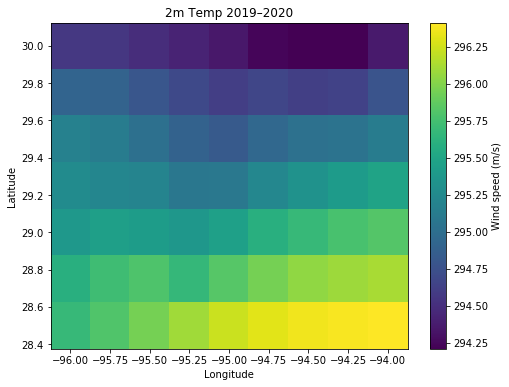

In [28]:
era5 = xr.open_dataset("/shared_space/Galveston_Bay/ERA5/ERA5-2019-2020_v3.nc")
era5

# Compute the mean wind speed over time
sst = era5['t2m'].mean(dim='valid_time')

# Plot the 2D spatial pattern
plt.figure(figsize=(8,6))
sst.plot(
    cmap='viridis',
    cbar_kwargs={'label': 'Wind speed (m/s)'}
)
plt.title("2m Temp 2019–2020")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


(7, 9) → (28, 36)


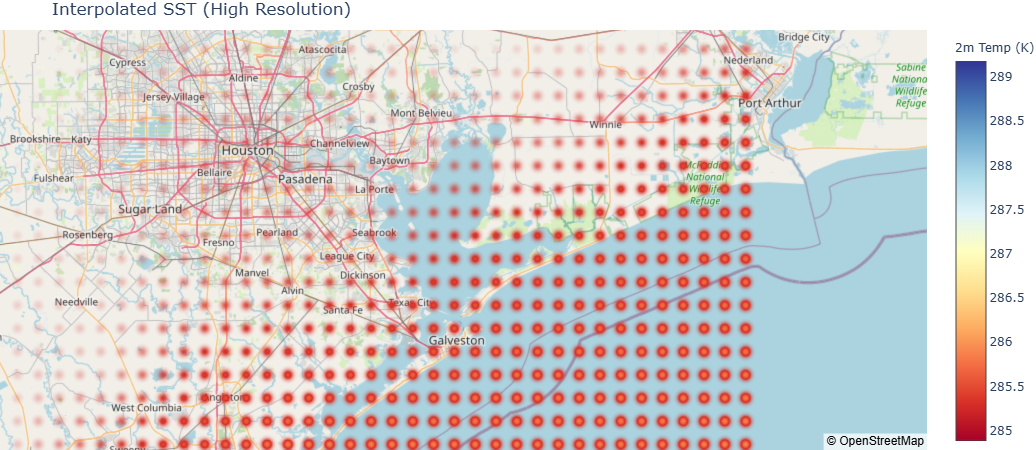

In [30]:
import xarray as xr
import numpy as np

# Load dataset
ds = xr.open_dataset("/shared_space/Galveston_Bay/ERA5/ERA5-2019-2020_v3.nc")

# Choose single time slice
t_sel = np.datetime64("2019-01-01T00:00:00")
sst = ds["t2m"].sel(valid_time=t_sel)

# (Optional) convert from Kelvin to °C if needed
# sst = sst - 273.15

# Original coords
lats = sst["latitude"].values
lons = sst["longitude"].values

# Define finer‑resolution grid (for example, 4× finer)
lat_hr = np.linspace(lats.min(), lats.max(), len(lats)*4)
lon_hr = np.linspace(lons.min(), lons.max(), len(lons)*4)

# Interpolate SST to the finer grid
sst_hr = sst.interp(latitude=lat_hr, longitude=lon_hr)

# Verify new dimensions
print(sst.shape, "→", sst_hr.shape)

import plotly.graph_objects as go

lon2d, lat2d = np.meshgrid(sst_hr.longitude, sst_hr.latitude)

fig = go.Figure(go.Densitymapbox(
    lon=lon2d.flatten(),
    lat=lat2d.flatten(),
    z=sst_hr.values.flatten(),
    radius=10,
    colorscale="rdylbu",
    colorbar=dict(title="2m Temp (K)"),
    name="High‑Res SST"
))

# Map extent and layout
extent = [-95.1, -94.45, 29.29, 29.8]
center_lon = np.mean(extent[:2])
center_lat = np.mean(extent[2:])

fig.update_layout(
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=8
    ),
    margin={"r":0,"t":30,"l":0,"b":0},
    title="Interpolated SST (High Resolution)"
)

fig.show()